## Generate dataset for multiplication only

- a from [0, 1000]
- b from [0, 1000]

Format is JSON:
```
[
    {
       input: [a, b],
       target: a * b
    }
    ...
    ...
]
```

In [1]:
import random
import json

dataset = []

unique_size = 20_000
unique_max_num = 1000

repeat_size = 5_000
repeat_max_num = 100

for _ in range(repeat_size):
    a = random.randint(0, repeat_max_num)
    b = random.randint(0, repeat_max_num)
    target = a * b
    data = {
        'input': { 'a': str(a), 'b': str(b) },
        'target': str(target)
    }
    dataset.append(data)

for _ in range(unique_size):
    a = random.randint(0, unique_max_num)
    b = random.randint(0, unique_max_num)
    target = a * b
    data = {
        'input': { 'a': str(a), 'b': str(b) },
        'target': str(target)
    }
    dataset.append(data)

print(json.dumps(dataset[:5], indent=4))
print(f"completed dataset creation of size {len(dataset)}....")

[
    {
        "input": {
            "a": "10",
            "b": "75"
        },
        "target": "750"
    },
    {
        "input": {
            "a": "90",
            "b": "72"
        },
        "target": "6480"
    },
    {
        "input": {
            "a": "76",
            "b": "6"
        },
        "target": "456"
    },
    {
        "input": {
            "a": "89",
            "b": "78"
        },
        "target": "6942"
    },
    {
        "input": {
            "a": "26",
            "b": "39"
        },
        "target": "1014"
    }
]
completed dataset creation of size 25000....


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from tokenizer import DigitTokenizer
from train_util import Trainer
from tqdm.auto import tqdm

DATA_DIR = "/teamspace/studios/this_studio/SAIR-competition-modular-math/data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

rand_seed = 42

batch_size = 64
max_seq_len = 12 # very small context window...
d_model = 512
num_heads = 4
lr = 1e-4

Training on device: cuda


In [3]:
tokenizer = DigitTokenizer()
eos_id = tokenizer.char_to_int["<eos>"]
pad_id = tokenizer.char_to_int["<pad>"]
tokenized_input = []

for sample in dataset:
    input_obj = sample["input"]
    str_tgt = sample["target"]
    str_a = input_obj['a']
    str_b = input_obj['b']

    a_token_id = tokenizer.encode(str_a)
    b_token_id = tokenizer.encode(str_b)
    tgt_token_id = tokenizer.encode(str_tgt)
    # KEY DECISION: reversing each input token so QKt aligns during math operations digit wise, from small to big
    a_token_id.reverse(), b_token_id.reverse(), tgt_token_id.reverse()
    tgt_token_id.append(eos_id)

    if len(a_token_id) < max_seq_len:
        a_token_id = a_token_id + [pad_id] * (max_seq_len - len(a_token_id))
    else:
        a_token_id = a_token_id[:max_seq_len]
    
    if len(b_token_id) < max_seq_len:
        b_token_id = b_token_id + [pad_id] * (max_seq_len - len(b_token_id))
    else:
        b_token_id = b_token_id[:max_seq_len]
    
    if len(tgt_token_id) < max_seq_len:
        tgt_token_id = tgt_token_id + [pad_id] * (max_seq_len - len(tgt_token_id))
    else:
        tgt_token_id = tgt_token_id[:max_seq_len]

    tokenized_input.append([a_token_id, b_token_id, tgt_token_id])


dataset_tensor = torch.tensor(tokenized_input, dtype=torch.long)

print(f"Dataset securely loaded in-memory. Matrix shape: {dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(dataset_tensor[:3])

Dataset securely loaded in-memory. Matrix shape: torch.Size([25000, 3, 12])
The <eos> token id is: 14
tensor([[[ 0,  1, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 5,  7, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 0,  5,  7, 14, 13, 13, 13, 13, 13, 13, 13, 13]],

        [[ 0,  9, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 2,  7, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 0,  8,  4,  6, 14, 13, 13, 13, 13, 13, 13, 13]],

        [[ 6,  7, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 6, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
         [ 6,  5,  4, 14, 13, 13, 13, 13, 13, 13, 13, 13]]])


In [4]:
train_loader, val_loader, test_loader = Trainer.dataset_tensor_to_loader(
    dataset_tensor,
    train_percent = 0.8,
    val_percent = 0.1,
    batch_size = batch_size,
    rand_seed = rand_seed,
)

print(f"Train Loader: {len(train_loader)} batches")
print(f"Val Loader:   {len(val_loader)} batches")
print(f"Test Loader:  {len(test_loader)} batches")

Train Loader: 312 batches
Val Loader:   40 batches
Test Loader:  40 batches


In [5]:
tokenized_standard_input = []

for sample in dataset:
    input_obj = sample["input"]
    str_tgt = sample["target"]
    str_a = input_obj['a']
    str_b = input_obj['b']
    
    standard_str_input = f"{str_a}*{str_b}={str_tgt}"
    standard_encoded_input = tokenizer.encode(standard_str_input)
    standard_encoded_input.append(eos_id)
    
    if len(standard_encoded_input) < 64:
        standard_encoded_input = standard_encoded_input + [pad_id] * (64 - len(standard_encoded_input))
    else:
        standard_encoded_input = standard_encoded_input[:64]

    tokenized_standard_input.append(standard_encoded_input)


standard_dataset_tensor = torch.tensor(tokenized_standard_input, dtype=torch.long)

print(f"Standard dataset securely loaded in-memory. Matrix shape: {standard_dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(standard_dataset_tensor[:3])

Standard dataset securely loaded in-memory. Matrix shape: torch.Size([25000, 64])
The <eos> token id is: 14
tensor([[ 1,  0, 10,  7,  5, 12,  7,  5,  0, 14, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [ 9,  0, 10,  7,  2, 12,  6,  4,  8,  0, 14, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13],
        [ 7,  6, 10,  6, 12,  4,  5,  6, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13, 13, 13, 13, 13, 13, 13]])


In [6]:
train_loader_std, val_loader_std, test_loader_std = Trainer.dataset_tensor_to_loader(
    standard_dataset_tensor,
    train_percent = 0.8,
    val_percent = 0.1,
    batch_size = batch_size,
    rand_seed = rand_seed,
)

print(f"Train Loader: {len(train_loader_std)} batches")
print(f"Val Loader:   {len(val_loader_std)} batches")
print(f"Test Loader:  {len(test_loader_std)} batches")

Train Loader: 312 batches
Val Loader:   40 batches
Test Loader:  40 batches


In [7]:
'''
Using standard GPT2 transformer model as baseline
'''
from transformers import GPT2Config, GPT2LMHeadModel

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,   
    n_embd=512,                       
    n_layer=2,                         
    n_head=4,                          
    n_ctx=64,                        
    bos_token_id=None,                 
    eos_token_id=tokenizer.char_to_int["<eos>"], 
    pad_token_id=tokenizer.char_to_int["<pad>"]
)

baseline_model = GPT2LMHeadModel(config).to(device)

num_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params:,}")

Total Trainable Parameters: 6,838,272


In [8]:
'''
Training loop for baseline model...
'''

vocab_size = tokenizer.vocab_size

std_trainer = Trainer(device=device)
std_optimizer = optim.AdamW(baseline_model.parameters(), lr=lr, weight_decay=0.1)
std_loss_fct = nn.CrossEntropyLoss(ignore_index=pad_id)

def train_model(num_epochs_to_add: int):
    start_epoch = len(std_trainer.train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add

    for epoch in range(start_epoch, target_epoch):
        baseline_model.train()
        total_train_loss = 0.0

        for batch_sequences in tqdm(train_loader_std, desc=f"Epoch {epoch+1} Training"):
            batch_sequences = batch_sequences.to(device)
            inputs  = batch_sequences[:, :-1].contiguous()
            targets = batch_sequences[:, 1:].contiguous()
            attention_mask = (inputs != pad_id).long()

            std_optimizer.zero_grad()
            logits = baseline_model(inputs, attention_mask=attention_mask).logits
            loss = std_loss_fct(logits.view(-1, vocab_size), targets.view(-1))
            loss.backward()
            std_optimizer.step()
            total_train_loss += loss.item()

        baseline_model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_sequences in tqdm(val_loader_std, desc=f"Epoch {epoch+1} Validation"):
                batch_sequences = batch_sequences.to(device)
                inputs  = batch_sequences[:, :-1].contiguous()
                targets = batch_sequences[:, 1:].contiguous()
                attention_mask = (inputs != pad_id).long()
                logits = baseline_model(inputs, attention_mask=attention_mask).logits
                loss = std_loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader_std)
        avg_val_loss   = total_val_loss / len(val_loader_std)
        std_trainer.add_loss(avg_train_loss, avg_val_loss)

        std_trainer.plot_live_loss(
            current_epoch=epoch,
            total_target_epochs=target_epoch
        )

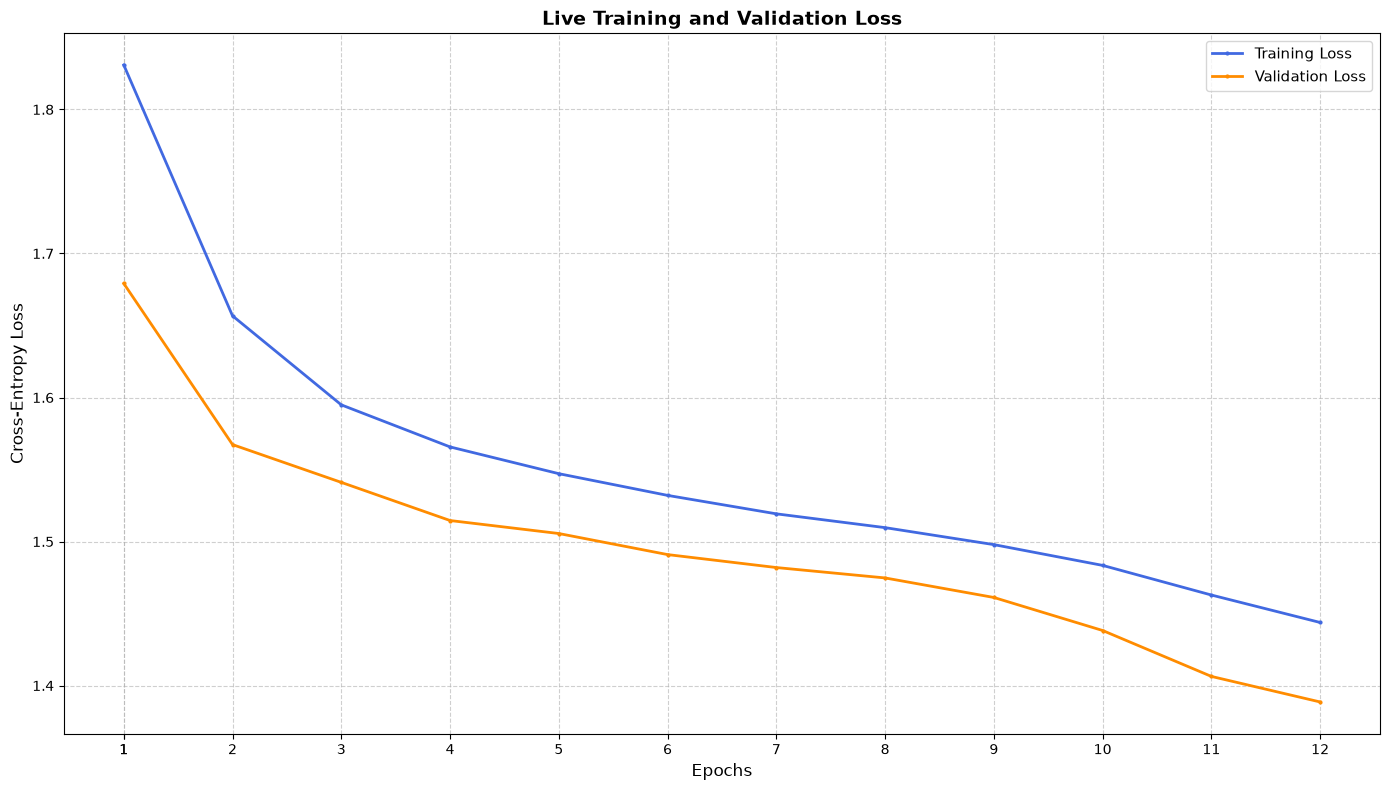

Latest Stats -> Epoch 11/30 | Train Loss: 1.4438 | Val Loss: 1.3886


Epoch 13 Training:   0%|          | 0/312 [00:00<?, ?it/s]

In [ ]:
train_model(20)

In [38]:
'''
Just trying to see if this setup can even learn simple multiplication first...
'''
from rope import RoPE

d_k = d_model // num_heads
rope = RoPE(
    d_head=d_k,
    max_seq_len=max_seq_len
)
embedding = nn.Embedding(num_embeddings=tokenizer.vocab_size, embedding_dim=d_model)
pre_attention_layernorm = nn.LayerNorm(d_model)
q_linear = nn.Linear(d_model, d_model)
k_linear = nn.Linear(d_model, d_model)
ffn = nn.Sequential(
            nn.Linear(max_seq_len, 2 * max_seq_len),
            nn.ReLU(),                                 
            nn.Linear(2 * max_seq_len, max_seq_len)
        )
final_layernorm = nn.LayerNorm(max_seq_len)
output_linear = nn.Linear(max_seq_len, tokenizer.vocab_size)



# single run with 1 sample for training
sample = dataset_tensor[0]
a, b, tgt = sample

a_embed = embedding(a)
b_embed = embedding(b)

a_norm1 = pre_attention_layernorm(a_embed)
b_norm1 = pre_attention_layernorm(b_embed)

q = q_linear(a_norm1).view(max_seq_len, num_heads, d_k).transpose(0, 1)
k = k_linear(b_norm1).view(max_seq_len, num_heads, d_k).transpose(0, 1)

q, k = rope(q, k)
score = torch.matmul(q, k.transpose(-2, -1)) / (d_k ** 0.5)
# explicitly skip softmax, and v ....
ffn_out = ffn(score)
final_norm = final_layernorm(ffn_out)
logits = output_linear(final_norm)
